## VIT (Vision Transformer)

In [ ]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import matplotlib.pyplot as plt

# 1. 모델 및 프로세서 로드  
model_name = "google/vit-base-patch16-224" # https://huggingface.co/google/vit-base-patch16-224
processor = ViTImageProcessor.from_pretrained(model_name)       # 이미지 정규화 전처리
model = ViTForImageClassification.from_pretrained(model_name)


In [ ]:
# 2. 테스트용 이미지 로드 (COCO 데이터셋의 고양이 사진)
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# 3. 이미지 전처리 및 텐서 변환
inputs = processor(images=image, return_tensors="pt")

# 4. 모델 추론 (Forward Pass)
model.eval()
with torch.no_grad():
    outputs = model(**inputs)



예측 완료: Egyptian cat


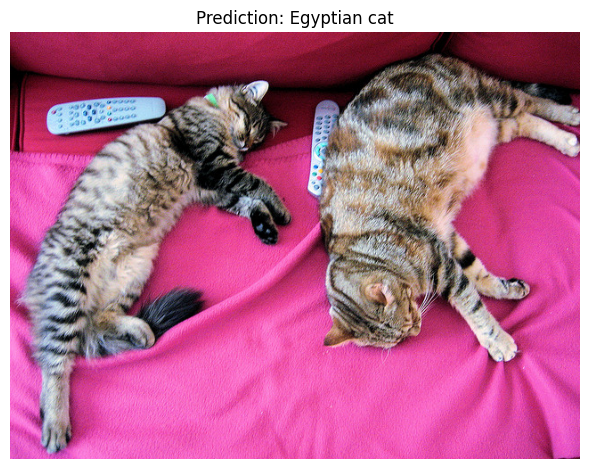

In [ ]:
# 5. 결과 확인 및 클래스 이름 추출
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_class_name = model.config.id2label[predicted_class_idx]

print(f"\n예측 완료: {predicted_class_name}")

# 6. Matplotlib으로 이미지와 예측 결과 직관적으로 시각화
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Prediction: {predicted_class_name}")
plt.axis('off') # 지저분한 축(눈금) 제거
plt.tight_layout()
plt.show()